In [36]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from collections import defaultdict
from pathlib import Path


# Support running Jupyter either from the repository root or notebooks/.
NOTEBOOK_ROOT = (
  Path(".")
  if Path("trie_logs").exists()
  else Path("notebooks")
)


def read_logs(log_type, path, config_names):
    """Read timestamped MESSI CSVs in their execution order.

    The filenames contain timestamps rather than configuration names.
    run_suite.sh emits the configurations in config_names order, so the
    chronologically sorted files are paired with that same order.
    """
    root = Path(path)
    result = defaultdict(dict)

    for log_dir in sorted(root.glob(f"*/*/{log_type}")):
        valid_files = [
            file
            for file in sorted(log_dir.glob("*.csv"))
            if file.stat().st_size > 0
        ]

        if len(valid_files) != len(config_names):
            print(
                f"WARNING: {log_dir} has {len(valid_files)} valid CSVs, "
                f"but {len(config_names)} config names"
            )

        for config, file in zip(config_names, valid_files):
            result[str(log_dir)][config] = str(file)

    return dict(result)

def load_current_index_results():
  rows = []

  # ---------------------------------------------------------
  # MESSI, SOFA, and iSAX + SPARTAN
  # ---------------------------------------------------------

  isax_configs = [
      "SAX",
      "SOFA+ED",
      "SOFA+EW",
      "SPARTAN+ED",
      "SPARTAN+EW",
  ]

  method_names = {
      "SAX": "MESSI",
      "SOFA+EW": "SOFA",
      "SPARTAN+ED": "iSAX SPARTAN",
  }

  isax_files = read_logs(
      log_type="index",
      path=str(NOTEBOOK_ROOT / "trie_logs/logs_SOFA_dyn_new"),
      config_names=isax_configs,
  )

  for _, files in isax_files.items():
      for config_name, filename in files.items():
          if config_name not in method_names:
              continue

          path = Path(filename)
          workers = int(path.parents[1].name)
          dataset = path.parents[2].name.upper()

          frame = pd.read_csv(path)
          frame.columns = frame.columns.str.strip()

          for _, row in frame.iterrows():
              learning = float(row["binning"]) / 1e6

              # This legacy field contains accumulated worker time.
              transformation = (
                  float(row["transformation"])
                  / 1e6
                  / workers
              )

              construction = (
                  float(row["indexing total"]) / 1e6
              )

              rows.append({
                  "Method": method_names[config_name],
                  "config": workers,
                  "dataset": dataset,
                  "Learning Bins": learning,
                  "Transformation": transformation,
                  "Indexing": max(
                      0.0,
                      construction - transformation,
                  ),
              })

  # ---------------------------------------------------------
  # S³-Trie
  #
  # The detailed phase breakdown is stored in the textual logs:
  #   binning total
  #   read / transform / split / compact / total
  # ---------------------------------------------------------

  trie_root = (
      NOTEBOOK_ROOT
      / "trie_logs"
      / (
          "logs_TRIE_64dim_ivf16_ball_avx512_"
          "radial_record_parallel_simd-residual-record-only"
      )
  )

  ansi_escape = re.compile(r"\x1b\[[0-9;]*m")

  for logfile in sorted(trie_root.glob("*/*/*.log")):
      workers = int(logfile.parent.name)

      text = logfile.read_text(
          encoding="utf-8",
          errors="replace",
      )
      text = ansi_escape.sub("", text)

      # One suite log can contain several methods.
      blocks = re.split(
          r"(?=^Running dataset=)",
          text,
          flags=re.MULTILINE,
      )

      for block in blocks:
          header = re.search(
              r"^Running dataset=(\S+).*method=(\S+)",
              block,
              flags=re.MULTILINE,
          )

          if header is None:
              continue

          dataset, method = header.groups()

          # Use SPARTAN equal-depth for the S³-Trie bar.
          if method != "spartan-depth":
              continue

          binning = re.search(
              r"SPARTAN binning timing:.*?"
              r"total=([0-9.]+)s",
              block,
          )

          build = re.search(
              r">>> trie build timing\s*"
              r"read\s*:\s*([0-9.]+)\s*s\s*"
              r"transform\s*:\s*([0-9.]+)\s*s\s*"
              r"split\s*:\s*([0-9.]+)\s*s\s*"
              r"compact\s*:\s*([0-9.]+)\s*s\s*"
              r"total\s*:\s*([0-9.]+)\s*s",
              block,
          )

          if binning is None or build is None:
              print(
                  "Skipping incomplete S3 build log:",
                  logfile,
              )
              continue

          read_s, transform_s, split_s, compact_s, total_s = (
              map(float, build.groups())
          )

          rows.append({
              "Method": "$S^3$-Trie",
              "config": workers,
              "dataset": dataset.upper(),
              "Learning Bins": float(binning.group(1)),
              "Transformation": transform_s,

              # Everything except transformation remains index
              # organization: input loading, splitting/IVF, and
              # final compaction.
              "Indexing": read_s + split_s + compact_s,
          })

  # ---------------------------------------------------------
  # DIDS
  # ---------------------------------------------------------

  dids_root = NOTEBOOK_ROOT / "logs" / "DIDS_logs"

  for path in sorted(dids_root.glob("*/threads-*/build.csv")):
      frame = pd.read_csv(path)
      frame.columns = frame.columns.str.strip()

      for _, row in frame.iterrows():
          # Older DIDS logs expose only the total construction time.
          # Keep those runs and assign their unavailable phase split to
          # the final index-organization component.
          learning = float(row.get("reference_selection_seconds", 0.0))
          transformation = float(row.get("grouping_seconds", 0.0))
          total = float(row["index_build_seconds"])

          rows.append({
              "Method": "DIDS",
              "config": int(row["threads"]),
              "dataset": str(row["dataset_id"]).upper(),

              # Map DIDS's analogous construction phases onto the
              # common stacked-bar decomposition.
              "Learning Bins": learning,
              "Transformation": transformation,
              "Indexing": max(
                  0.0,
                  total - learning - transformation,
              ),
          })


  # ---------------------------------------------------------
  # FAISS
  # ---------------------------------------------------------

  faiss_root = (
      NOTEBOOK_ROOT
      / "logs"
      / "FAISS_L2_logs_mini_batch"
      / "64"
  )

  for path in sorted(faiss_root.glob("index_*_64.csv")):
      dataset = path.stem
      dataset = dataset.removeprefix("index_")
      dataset = dataset.removesuffix("_64").upper()

      frame = pd.read_csv(path)
      frame.columns = frame.columns.str.strip()

      creation_column = next(
          column
          for column in frame.columns
          if "index creation time" in column
      )

      for value in frame[creation_column]:
          rows.append({
              "Method": "FAISS",
              "config": 64,
              "dataset": dataset,
              "Learning Bins": 0.0,
              "Transformation": 0.0,
              "Indexing": float(value) / 1000,
          })

  result = pd.DataFrame(rows)

  if result.empty:
      raise RuntimeError("No index-construction results were loaded")

  return result


index_subset = load_current_index_results()

In [42]:
INDEX_PHASES = ["Learning Bins", "Transformation", "Indexing"]

INDEX_COLORS = {
    "Learning Bins": "#d95f02",
    "Transformation": "#66a89c",
    "Indexing": "#4c78a8",
}

INDEX_METHOD_ORDER = [
    "MESSI",
    "SOFA",
    "DIDS",
    "$S^3$-Trie",
]


def plot_index_creation(
    index_subset,
    workers=None,
    datasets=None,
    output="images/experiment_index_creation.pdf",
):
    data = index_subset.copy()

    # Exclude iSAX SPARTAN.
    data = data[data["Method"] != "iSAX SPARTAN"].copy()

    data["config"] = (
        data["config"]
        .astype(str)
        .str.lstrip("0")
        .replace("", "0")
        .astype(int)
    )

    if datasets is not None:
        selected = {name.upper() for name in datasets}
        data = data[data["dataset"].str.upper().isin(selected)].copy()
        dataset_count = data["dataset"].nunique()
    else:
        # Aggregate only over datasets represented by every method; in
        # particular, DIDS currently lacks a completed Iquique build.
        dataset_sets = [
            set(group["dataset"].str.upper())
            for _, group in data.groupby("Method")
        ]
        common_datasets = set.intersection(*dataset_sets)
        data = data[
            data["dataset"].str.upper().isin(common_datasets)
        ].copy()
        dataset_count = len(common_datasets)

    if workers is None:
        workers = sorted(data["config"].unique())

    workers = [int(w) for w in workers]

    method_order = [
        m for m in INDEX_METHOD_ORDER
        if m in data["Method"].unique()
    ]

    method_order += [
        m for m in data["Method"].unique()
        if m not in method_order
    ]

    panels = {}
    global_max = 0

    for worker_count in workers:
        panel = (
            data[data["config"] == worker_count]
            .groupby("Method")[INDEX_PHASES]
            .mean()
            .reindex(method_order)
            .dropna(how="all")
        )

        panels[worker_count] = panel

        if not panel.empty:
            global_max = max(
                global_max,
                panel.sum(axis=1).max(),
            )

    with plt.style.context({
        "font.size": 13,
        "axes.titlesize": 15,
        "axes.labelsize": 14,
        "xtick.labelsize": 13,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
    }):
        fig_width = max(7.2, 4.2 * len(workers))

        fig, axes = plt.subplots(
            1,
            len(workers),
            figsize=(fig_width, 3.6),
            sharey=True,
            squeeze=False,
        )

        axes = axes.ravel()

        legend_handles = None
        legend_labels = None

        for i, (ax, worker_count) in enumerate(zip(axes, workers)):
            panel = panels[worker_count]

            panel.plot(
                kind="bar",
                stacked=True,
                ax=ax,
                width=0.72,
                color=[INDEX_COLORS[p] for p in INDEX_PHASES],
                edgecolor="white",
                linewidth=0.6,
                legend=True,
            )

            totals = panel.sum(axis=1)

            for x, total in enumerate(totals):
                ax.annotate(
                    f"{total:.1f}s",
                    xy=(x, total),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=11.5,
                    fontweight="semibold",
                    color="#333333",
                )

            if legend_handles is None:
                legend_handles, legend_labels = (
                    ax.get_legend_handles_labels()
                )

            if ax.get_legend() is not None:
                ax.get_legend().remove()

            ax.set_xlabel("")

            ax.set_ylim(
                0,
                global_max * 1.18,
            )

            # Clean horizontal x labels.
            ax.tick_params(
                axis="x",
                rotation=0,
                length=0,
                pad=6,
                labelsize=13,
            )

            ax.tick_params(
                axis="y",
                length=0,
                labelsize=12,
            )

            # Replace math-text label with cleaner Unicode display text.
            display_labels = []
            for label in ax.get_xticklabels():
                text = label.get_text()
                if text == "$S^3$-Trie":
                    text = "S³-Trie"
                display_labels.append(text)

            ax.set_xticklabels(display_labels)

            for label in ax.get_xticklabels():
                label.set_horizontalalignment("center")

                if label.get_text() == "S³-Trie":
                    label.set_fontweight("bold")
                    label.set_color("#d95f02")

            ax.grid(
                axis="y",
                linestyle=":",
                linewidth=0.8,
                alpha=0.25,
            )

            ax.set_axisbelow(True)

            if i == 0:
                ax.set_ylabel(
                    "Mean time (log-scale) [s]",
                    fontsize=14,
                )
            else:
                ax.set_ylabel("")

            sns.despine(
                ax=ax,
                top=True,
                right=True,
                left=True,
            )

        # Runtime labels inside each stacked segment.
        for x, (_, row) in enumerate(panel.iterrows()):
            bottom = 0.0
        
            for phase in INDEX_PHASES:
                value = row[phase]
        
                if pd.isna(value) or value <= 0:
                    continue
        
                center = bottom + value / 2
        
                ax.annotate(
                    f"{value:.1f}s",
                    xy=(x, center),
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="semibold",
                    color="#222222",
                    bbox=dict(
                        boxstyle="round,pad=0.18",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.8,
                    ),
                )
        
                bottom += value
                
        title = "Index construction time"
        ax.set_yscale("symlog")

        fig.suptitle(
            title,
            fontsize=18,
            fontweight="bold",
            y=0.98,
        )

        # Legend below the entire figure.
        fig.legend(
            legend_handles,
            legend_labels,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.01),
            ncol=len(INDEX_PHASES),
            frameon=False,
            fontsize=13,
            handlelength=1.3,
            columnspacing=1.5,
        )

        # Manual spacing: room for x labels + bottom legend.
        fig.subplots_adjust(
            left=0.09,
            right=0.985,
            bottom=0.26,
            top=0.84,
            wspace=0.18,
        )

        if output is not None:
            fig.savefig(
                output,
                bbox_inches="tight",
                pad_inches=0.02,
            )

        return fig, axes

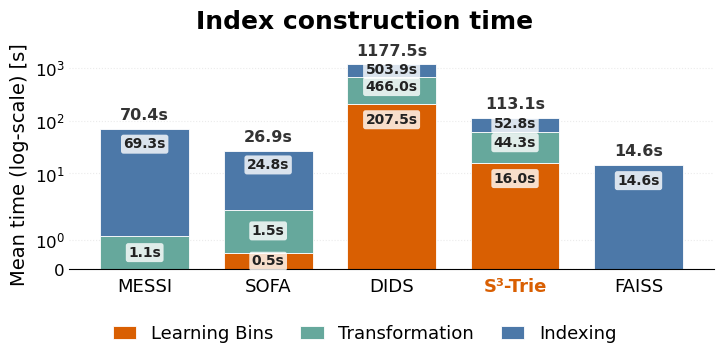

In [43]:
plot_index_creation(
      index_subset,
      workers=[64],
      output="images/experiment_index_creation_64.pdf",
)
plt.show()

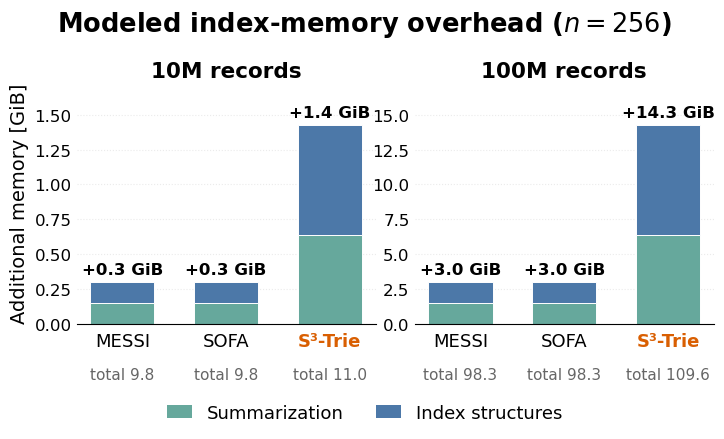

In [44]:
# Theoretical memory model -- these are estimates, not measured RSS.
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch


def model_index_memory(
    dataset_sizes=(10_000_000, 100_000_000),
    series_length=256,
    alphabet_size=256,
    leaf_capacity=20_000,
    isax_dimensions=16,
    trie_dimensions=64,
    trie_prefix_dimensions=64,
    trie_fanout=8,
    ivf_groups=16,
    allocated_child_slots=256,
):
    rows = []

    for records in dataset_sizes:
        raw = 4 * records * series_length
        leaves = int(np.ceil(records / leaf_capacity))

        # MESSI/SOFA
        isax_nodes = max(1, 2 * leaves - 1)
        isax_summary = records * isax_dimensions
        isax_records = 16 * records
        isax_tree = isax_nodes * (2 * isax_dimensions + 16)

        messi_index = isax_records + isax_tree

        sofa_model = (
            4 * isax_dimensions * (alphabet_size - 1)
            + 4 * isax_dimensions
        )
        sofa_summary = isax_summary + sofa_model

        # S3-Trie
        trie_nodes = int(np.ceil(
            (trie_fanout * leaves - 1) / (trie_fanout - 1)
        ))
        clusters = leaves * ivf_groups
        clustered_records = records

        trie_summary = (
            records * trie_dimensions
            + 4 * records
        )

        trie_index = (
            16 * records
            + records * trie_prefix_dimensions
            + trie_nodes * (
                2 * trie_dimensions
                + 8 * allocated_child_slots
            )
            + clusters * (
                4 * series_length
                + 2 * trie_dimensions
            )
            + 4 * clustered_records
        )

        for method, summary, index in [
            ("MESSI", isax_summary, messi_index),
            ("SOFA", sofa_summary, messi_index),
            (r"$S^3$-Trie", trie_summary, trie_index),
        ]:
            rows.append({
                "Records": records,
                "Method": method,
                "Raw bytes": raw,
                "Summarization bytes": summary,
                "Index bytes": index,
                "Total bytes": raw + summary + index,
            })

    return pd.DataFrame(rows)


def plot_modeled_memory(
    memory,
    output="images/theoretical_memory_scaling.pdf",
):
    methods = ["MESSI", "SOFA", r"$S^3$-Trie"]
    display_methods = ["MESSI", "SOFA", "S³-Trie"]

    sizes = sorted(memory["Records"].unique())
    gib = 1024**3

    fig, axes = plt.subplots(
        1,
        len(sizes),
        figsize=(7.2, 4.4),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, records in zip(axes, sizes):
        panel = (
            memory[memory["Records"] == records]
            .set_index("Method")
            .reindex(methods)
        )

        raw = panel["Raw bytes"].to_numpy() / gib
        summary = panel["Summarization bytes"].to_numpy() / gib
        index = panel["Index bytes"].to_numpy() / gib
        overhead = summary + index
        total = raw + overhead

        x = np.arange(len(methods))

        ax.bar(
            x,
            summary,
            width=0.62,
            color="#66a89c",
            edgecolor="white",
            linewidth=0.7,
            label="Summarization",
        )

        ax.bar(
            x,
            index,
            bottom=summary,
            width=0.62,
            color="#4c78a8",
            edgecolor="white",
            linewidth=0.7,
            label="Index structures",
        )

        # Overhead and total-memory annotations.
        for xpos, extra, total_mem in zip(x, overhead, total):
            ax.annotate(
                rf"+{extra:.1f} GiB",
                xy=(xpos, extra),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="semibold",
            )

            ax.annotate(
                rf"total {total_mem:.1f}",
                xy=(xpos, 0),
                xytext=(0, -31),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=11,
                color="#666666",
                annotation_clip=False,
            )

        ax.set_xticks(x, display_methods)

        ax.set_title(
            f"{records / 1e6:g}M records",
            fontsize=15.5,
            fontweight="semibold",
            pad=3,
        )

        ax.set_ylim(0, overhead.max() * 1.22)

        ax.grid(
            axis="y",
            linestyle=":",
            linewidth=0.8,
            alpha=0.25,
        )
        ax.set_axisbelow(True)

        ax.tick_params(
            axis="x",
            rotation=0,
            length=0,
            pad=6,
            labelsize=13,
        )

        ax.tick_params(
            axis="y",
            length=0,
            labelsize=12,
        )

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("center")

        labels = ax.get_xticklabels()
        labels[-1].set_color("#d95f02")
        labels[-1].set_fontweight("bold")

        sns.despine(
            ax=ax,
            top=True,
            right=True,
            left=True,
        )


    axes[0].set_ylabel(
        "Additional memory [GiB]",
        fontsize=14,
    )

    fig.suptitle(
        r"Modeled index-memory overhead ($n=256$)",
        fontsize=18.5,
        fontweight="bold",
        y=0.985,
    )

    # Legend below the entire figure.
    fig.legend(
        handles=[
            Patch(
                facecolor="#66a89c",
                label="Summarization",
            ),
            Patch(
                facecolor="#4c78a8",
                label="Index structures",
            ),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=2,
        frameon=False,
        fontsize=13,
        handlelength=1.4,
        columnspacing=1.8,
    )

    # Manual layout so title, panels, totals, and legend don't fight.
    fig.subplots_adjust(
        left=0.10,
        right=0.985,
        bottom=0.27,
        top=0.82,
        wspace=0.13,
    )

    if output is not None:
        fig.savefig(
            output,
            bbox_inches="tight",
            pad_inches=0.02,
        )

    return fig, axes


memory_model = model_index_memory()

plot_modeled_memory(memory_model)

plt.show()